<a href="https://colab.research.google.com/github/GogBean/Lab/blob/main/exp8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Decision Tree Accuracy: 90.32 %

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       434
           1       0.89      0.92      0.90       434

    accuracy                           0.90       868
   macro avg       0.90      0.90      0.90       868
weighted avg       0.90      0.90      0.90       868


Feature Importance:
TotalQuantity : 0.8638
NumberOfInvoices : 0.1362


[Text(0.5, 0.9, 'TotalQuantity <= 359.5\nentropy = 1.0\nsamples = 3470\nvalue = [1735, 1735]\nclass = Low Value'),
 Text(0.25, 0.7, 'TotalQuantity <= 241.5\nentropy = 0.417\nsamples = 1698\nvalue = [1555, 143]\nclass = Low Value'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'NumberOfInvoices <= 2.5\nentropy = 0.194\nsamples = 1274\nvalue = [1236, 38]\nclass = Low Value'),
 Text(0.0625, 0.3, 'NumberOfInvoices <= 1.5\nentropy = 0.11\nsamples = 1159\nvalue = [1142, 17]\nclass = Low Value'),
 Text(0.03125, 0.1, 'entropy = 0.05\nsamples = 889\nvalue = [884, 5]\nclass = Low Value'),
 Text(0.09375, 0.1, 'entropy = 0.262\nsamples = 270\nvalue = [258, 12]\nclass = Low Value'),
 Text(0.1875, 0.3, 'NumberOfInvoices <= 6.5\nentropy = 0.686\nsamples = 115\nvalue = [94, 21]\nclass = Low Value'),
 Text(0.15625, 0.1, 'entropy = 0.602\nsamples = 109\nvalue = [93, 16]\nclass = Low Value'),
 Text(0.21875, 0.1, 'entropy = 0.65\nsamples = 6\nvalue = [1, 5]\nclass = High Value'),
 Text(0.375, 0.5, 'Numb

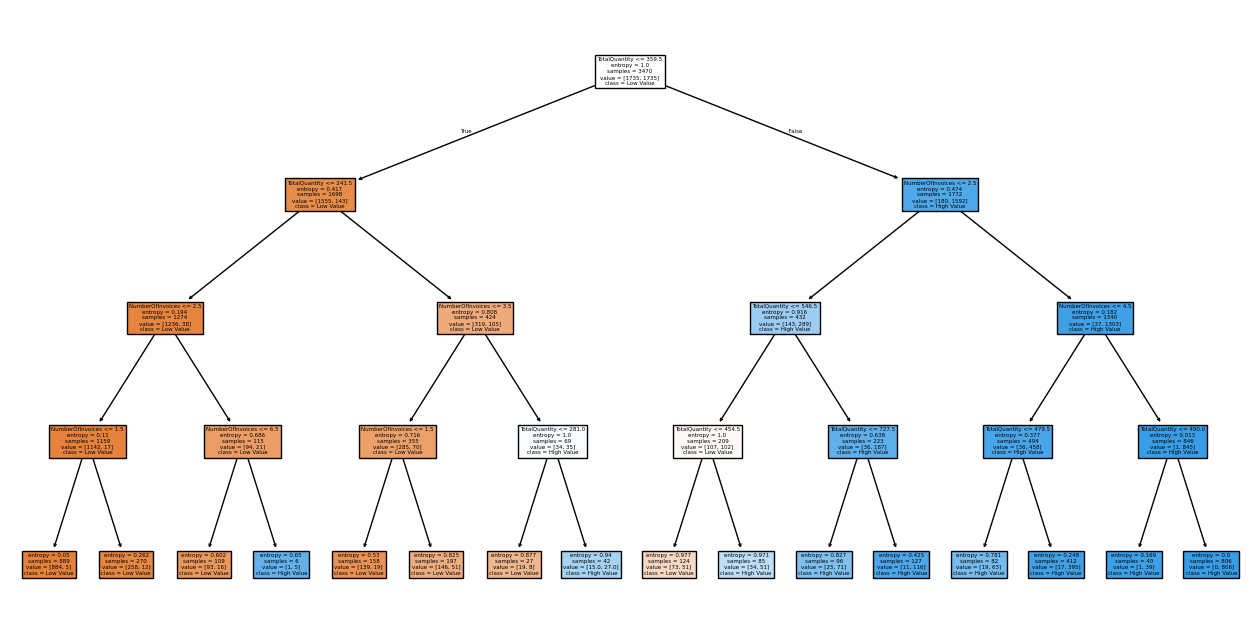

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, classification_report

# Load dataset directly from UCI repository url
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

# Remove missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove invalid transactions
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Calculate total amount
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Customer-level aggregation
customer_data = df.groupby("CustomerID").agg({
    "Quantity": "sum",
    "TotalAmount": "sum",
    "InvoiceNo": "nunique"
}).reset_index()

customer_data.columns = [
    "CustomerID", "TotalQuantity",
    "TotalAmount", "NumberOfInvoices"
]

# Create customer segment
median_amount = customer_data["TotalAmount"].median()
customer_data["Segment"] = (
    customer_data["TotalAmount"] >= median_amount
).astype(int)

# Features and target
X = customer_data[["TotalQuantity", "NumberOfInvoices"]]
y = customer_data["Segment"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ID3 Decision Tree
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

print("Decision Tree Accuracy:",
      round(accuracy_score(y_test, y_pred) * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nFeature Importance:")
for feature, importance in zip(
    X.columns, model.feature_importances_
):
    print(feature, ":", round(importance, 4))

# Visualize tree
plt.figure(figsize=(16, 8))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Low Value", "High Value"],
    filled=True
)